In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
train_data = pd.read_csv("playground-series-s5e11/train.csv")
X_train, X_val, y_train, y_val = train_test_split(
    train_data.drop(columns=["loan_paid_back"]),
    train_data["loan_paid_back"],
    test_size=0.2,
    random_state=42
)
X_train.shape, X_val.shape 

((475195, 12), (118799, 12))

In [3]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 475195 entries, 119010 to 121958
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    475195 non-null  int64  
 1   annual_income         475195 non-null  float64
 2   debt_to_income_ratio  475195 non-null  float64
 3   credit_score          475195 non-null  int64  
 4   loan_amount           475195 non-null  float64
 5   interest_rate         475195 non-null  float64
 6   gender                475195 non-null  object 
 7   marital_status        475195 non-null  object 
 8   education_level       475195 non-null  object 
 9   employment_status     475195 non-null  object 
 10  loan_purpose          475195 non-null  object 
 11  grade_subgrade        475195 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 47.1+ MB


In [4]:
X_train.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
count,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000
mean,297019.709145,48233.036340,0.120739,680.929448,15019.292035,12.356332
std,171485.447704,26724.934464,0.068617,55.440881,6927.745719,2.008128
min,1.000000,6008.560000,0.011000,395.000000,500.090000,3.320000
25%,148383.500000,27927.700000,0.072000,646.000000,10275.280000,10.990000
50%,297082.000000,46603.520000,0.096000,682.000000,15000.220000,12.370000
75%,445673.500000,61053.270000,0.157000,719.000000,18872.120000,13.680000
max,593992.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000


Check for any nulls

In [5]:
[col for col in train_data.columns if train_data[col].isna().any()]

[]

First, check the $y$'s distribution

In [6]:
if "id" in X_train.columns:
    X_train.drop(columns="id", inplace=True)
    X_val.drop(columns="id", inplace=True)

<Axes: >

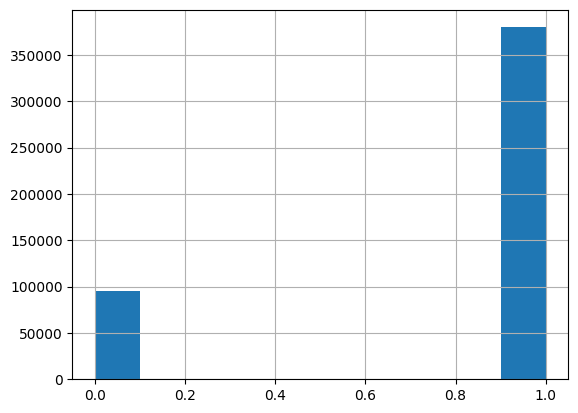

In [7]:
y_train.hist()

Check $y$'s distribution on others.

<Figure size 800x600 with 0 Axes>

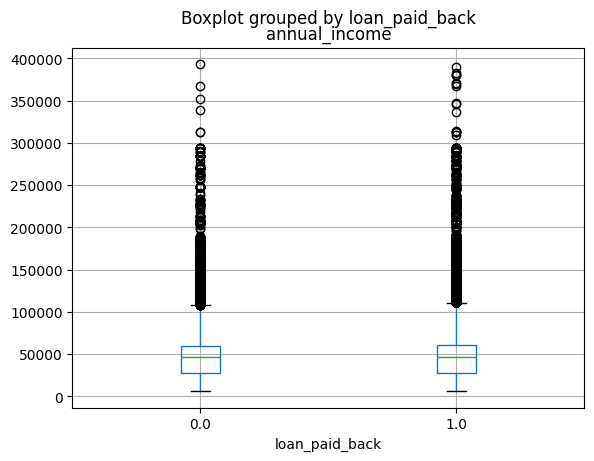

<Figure size 800x600 with 0 Axes>

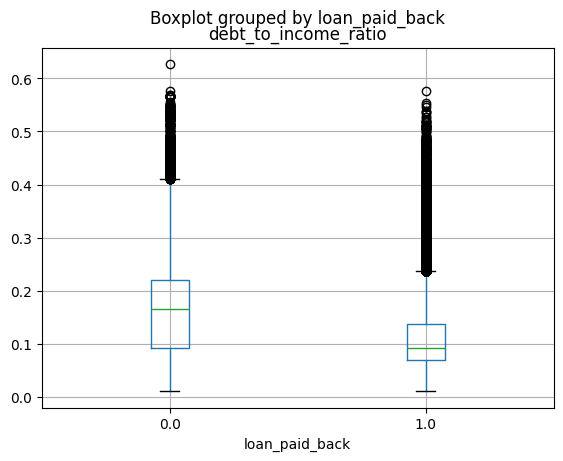

<Figure size 800x600 with 0 Axes>

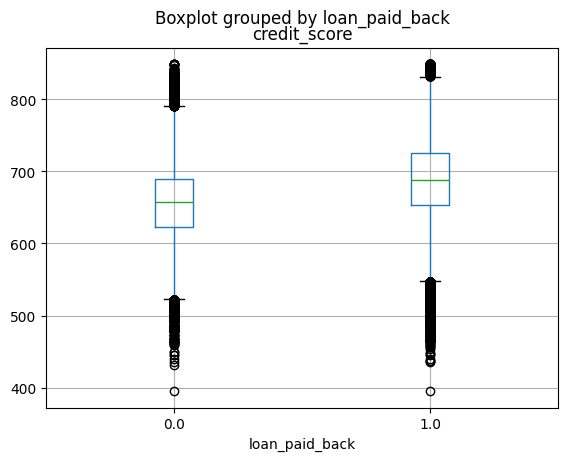

<Figure size 800x600 with 0 Axes>

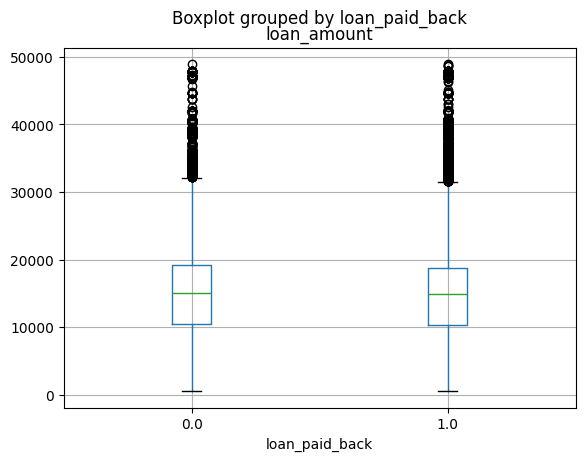

<Figure size 800x600 with 0 Axes>

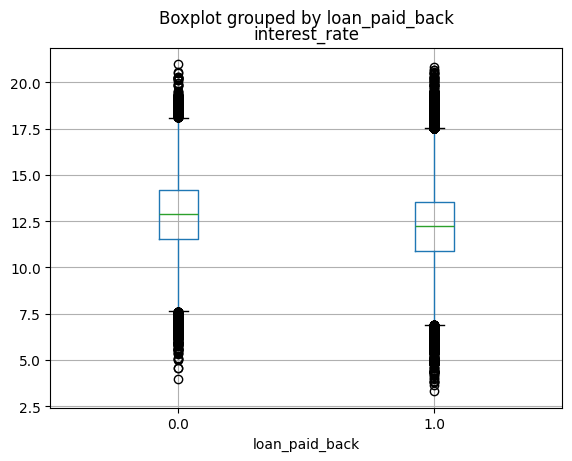

In [8]:
for i in X_train.columns:
    if X_train[i].dtype == "float64" or X_train[i].dtype == "int64":
        new_data = pd.concat([X_train[i], y_train], axis=1)
        plt.figure(figsize=(8, 6))
        new_data.boxplot(column=i, by="loan_paid_back")

In [9]:
from scipy.stats import ttest_ind

imp_num_features = []
for i in X_train.columns:
    if X_train[i].dtype == "float64" or X_train[i].dtype == "int64":
        group1 = X_train[y_train == 0][i]
        group2 = X_train[y_train == 1][i]
        tstat, pvalue = ttest_ind(group1, group2, nan_policy='omit')
        # print(f"{i}: t-statistic = {tstat}, p-value = {pvalue}")

        if pvalue < 0.05:
            # print(f"Significant difference in means for {i} between the two groups.")
            print(f"Feature '{i}' may be important for predicting 'loan_paid_back'.")
            imp_num_features.append(i)
        else:
            # print(f"No significant difference in means for {i} between the two groups.")
            print(f"Feature '{i}' may NOT be important for predicting 'loan_paid_back'.")

Feature 'annual_income' may be important for predicting 'loan_paid_back'.
Feature 'debt_to_income_ratio' may be important for predicting 'loan_paid_back'.
Feature 'credit_score' may be important for predicting 'loan_paid_back'.
Feature 'loan_amount' may be important for predicting 'loan_paid_back'.
Feature 'interest_rate' may be important for predicting 'loan_paid_back'.


In [10]:
from scipy.stats import chi2_contingency

imp_cat_features = []
for i in X_train.columns:
    if X_train[i].dtype == "object":
        # print(f"\nAnalyzing Categorical Feature: {i}")
        # 1. Create a Contingency Table (Cross-Tab)
        contingency_table = pd.crosstab(X_train[i], y_train)
        # 2. Run the Test
        stat, p_value, dof, expected = chi2_contingency(contingency_table)

        if p_value < 0.05:
            print(f"Reject Null: Variables are Dependent. Feature {i} is USEFUL.")
            imp_cat_features.append(i)
        else:
            print(f"Fail to Reject: Variables are Independent. Feature {i} is USELESS.")

Reject Null: Variables are Dependent. Feature gender is USEFUL.
Reject Null: Variables are Dependent. Feature marital_status is USEFUL.
Reject Null: Variables are Dependent. Feature education_level is USEFUL.
Reject Null: Variables are Dependent. Feature employment_status is USEFUL.
Reject Null: Variables are Dependent. Feature loan_purpose is USEFUL.
Reject Null: Variables are Dependent. Feature grade_subgrade is USEFUL.


Just to be safe, I am still keeping `marital_status` even though chi-square test says it is useless when ran on full train dataset. 

Try on Recursive Feature Elimination - RFE is overkill so just do normal 

In [11]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold


# 2. Define Preprocessing (The Critical Step)
# We must convert 'City' to numbers so the Model can read it
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), [i for i in X_train.select_dtypes(include=['object']).columns]),
        ('num', 'passthrough', [i for i in X_train.select_dtypes(include=['int64', 'float64']).columns])
    ])

# 3. Define the Estimator (Classifier for Categorical Target)
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)

# Create the Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf)
])

# Fit the Model
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

array(['cat__gender_Female', 'cat__gender_Male', 'cat__gender_Other',
       'cat__marital_status_Divorced', 'cat__marital_status_Married',
       'cat__marital_status_Single', 'cat__marital_status_Widowed',
       "cat__education_level_Bachelor's",
       'cat__education_level_High School',
       "cat__education_level_Master's", 'cat__education_level_Other',
       'cat__education_level_PhD', 'cat__employment_status_Employed',
       'cat__employment_status_Retired',
       'cat__employment_status_Self-employed',
       'cat__employment_status_Student',
       'cat__employment_status_Unemployed', 'cat__loan_purpose_Business',
       'cat__loan_purpose_Car', 'cat__loan_purpose_Debt consolidation',
       'cat__loan_purpose_Education', 'cat__loan_purpose_Home',
       'cat__loan_purpose_Medical', 'cat__loan_purpose_Other',
       'cat__loan_purpose_Vacation', 'cat__grade_subgrade_A1',
       'cat__grade_subgrade_A2', 'cat__grade_subgrade_A3',
       'cat__grade_subgrade_A4', 'cat__grad

In [13]:
rf_pipeline.named_steps["classifier"].feature_importances_

array([4.30203796e-04, 4.05039469e-04, 1.16605269e-04, 2.22721408e-04,
       4.11942284e-04, 4.18250153e-04, 1.48185623e-04, 4.89874267e-04,
       4.32006962e-04, 3.25133166e-04, 2.29466454e-04, 1.86945908e-04,
       1.46960665e-01, 2.38926770e-02, 2.80185325e-02, 5.13408657e-02,
       5.40088198e-01, 2.34100671e-04, 2.94523094e-04, 3.70909729e-04,
       3.09993281e-04, 2.74342888e-04, 2.24364176e-04, 2.83774485e-04,
       1.54275013e-04, 1.62792174e-04, 1.02059365e-04, 2.39284636e-04,
       6.67256416e-05, 2.04544975e-04, 7.07612368e-04, 2.04684629e-03,
       1.69465743e-03, 1.28080992e-03, 1.36746798e-03, 7.93325265e-04,
       4.61039479e-04, 3.99209714e-04, 5.60627023e-04, 4.20590622e-04,
       7.54385170e-04, 1.10585331e-03, 2.86514738e-03, 1.39391594e-03,
       9.39867119e-04, 1.45511856e-04, 7.96642604e-05, 4.39171141e-04,
       4.81575553e-04, 9.91149036e-05, 4.93073925e-04, 7.10735909e-04,
       8.10869734e-04, 8.18584676e-04, 4.66858516e-04, 3.19482924e-03,
      


--- Feature Importance Table ---
                                 Feature  Importance
16     cat__employment_status_Unemployed    0.540088
12       cat__employment_status_Employed    0.146961
56             num__debt_to_income_ratio    0.111635
15        cat__employment_status_Student    0.051341
57                     num__credit_score    0.048539
14  cat__employment_status_Self-employed    0.028019
13        cat__employment_status_Retired    0.023893
59                    num__interest_rate    0.014904
58                      num__loan_amount    0.003351
55                    num__annual_income    0.003195
42                cat__grade_subgrade_D3    0.002865
31                cat__grade_subgrade_B2    0.002047
32                cat__grade_subgrade_B3    0.001695
43                cat__grade_subgrade_D4    0.001394
34                cat__grade_subgrade_B5    0.001367
33                cat__grade_subgrade_B4    0.001281
41                cat__grade_subgrade_D2    0.001106
44          

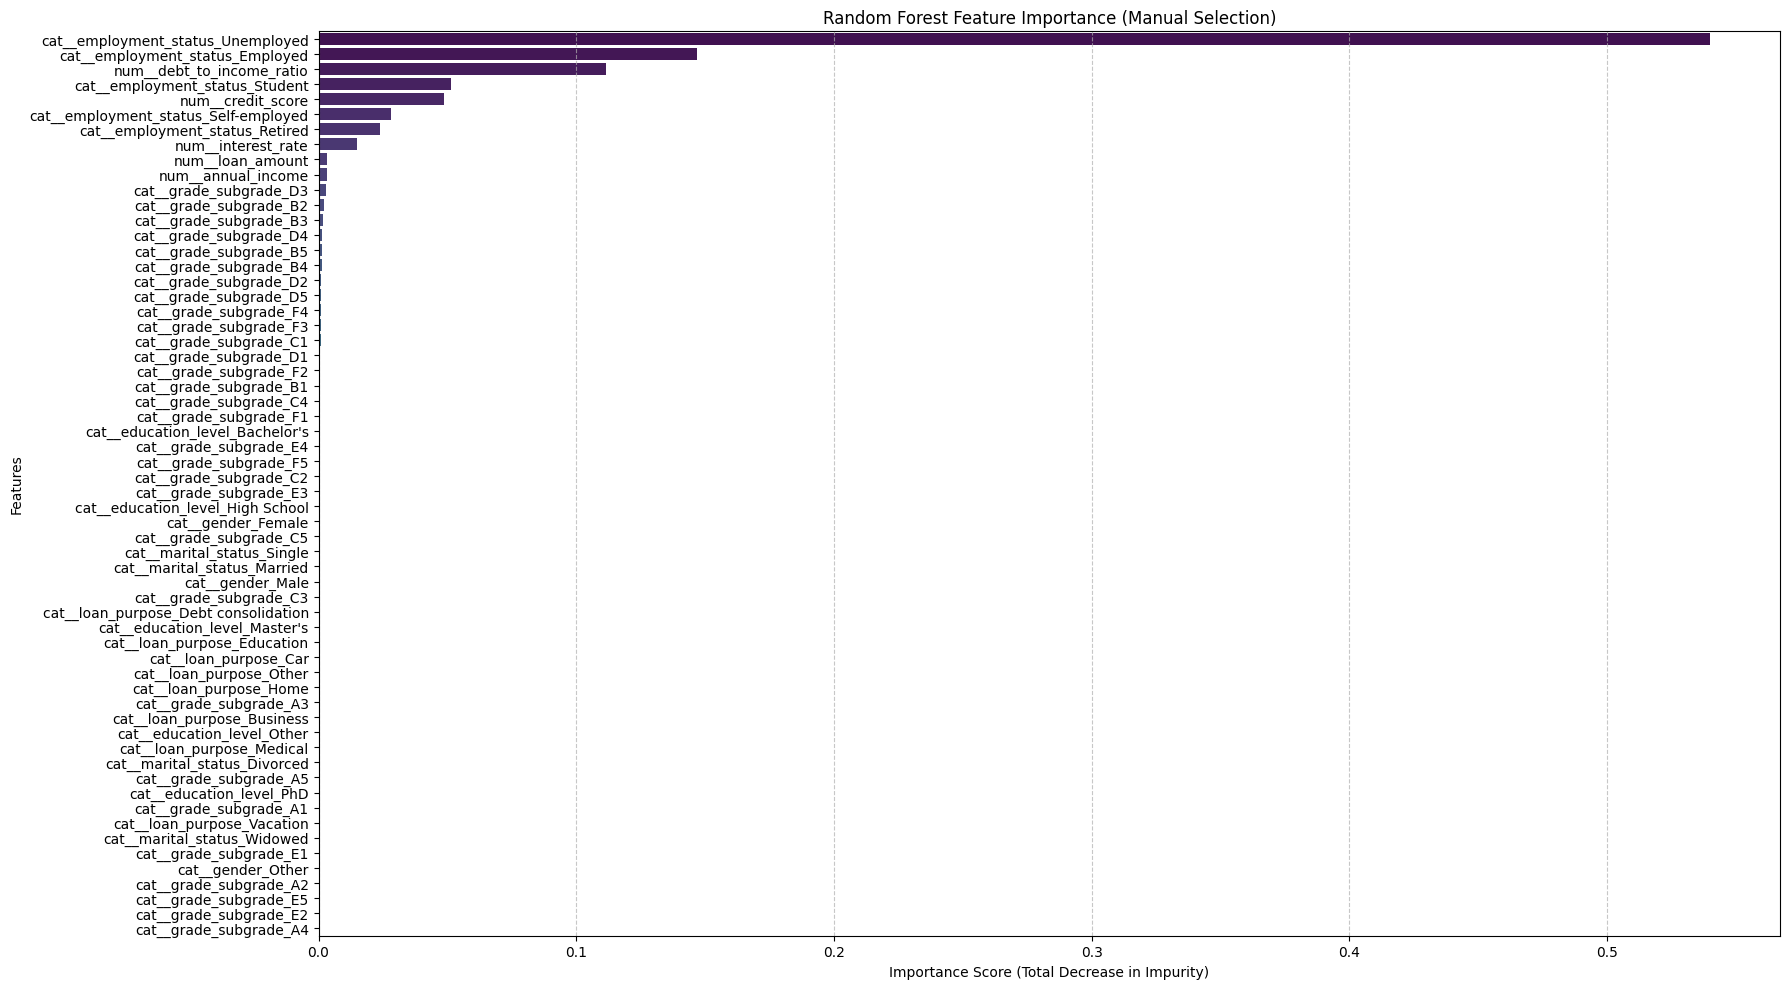

In [14]:
# 3. Extract and Sort Feature Importances
importances = rf_pipeline.named_steps['classifier'].feature_importances_
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Create a DataFrame for easy handling
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance Table ---")
print(feature_imp_df)

# 4. Plotting (The Visual Inspection)
plt.figure(figsize=(18, 10))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, hue='Feature', palette='viridis')

plt.title('Random Forest Feature Importance (Manual Selection)')
plt.xlabel('Importance Score (Total Decrease in Impurity)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

print("\nPlot generated. Look for the 'Elbow' where importance drops off.")
plt.show()


--- Aggregated Feature Importance ---
                 Feature  Importance
8      employment_status    0.790301
1   debt_to_income_ratio    0.111635
2           credit_score    0.048539
10        grade_subgrade    0.022112
4          interest_rate    0.014904
3            loan_amount    0.003351
0          annual_income    0.003195
9           loan_purpose    0.002146
7        education_level    0.001663
6         marital_status    0.001201
5                 gender    0.000952


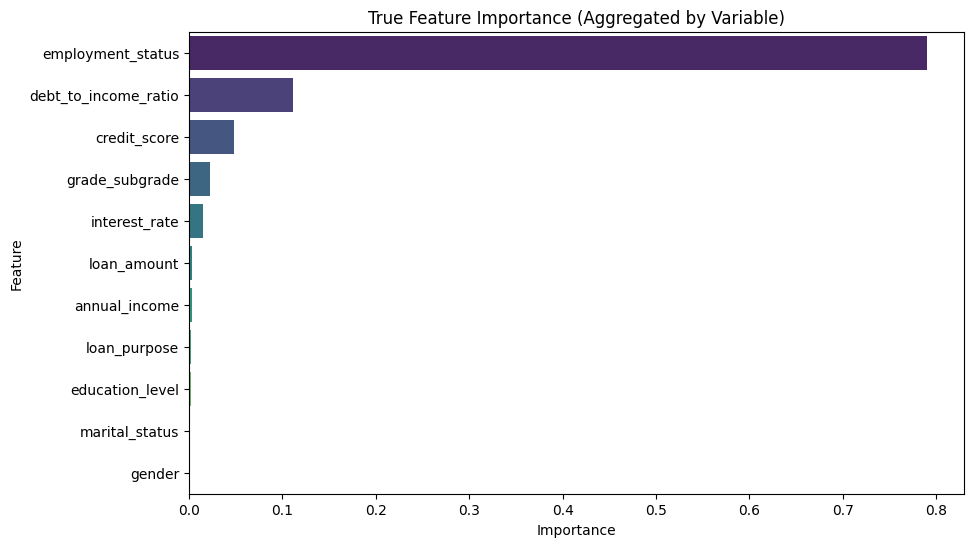


Recommended Features to Keep (> 0.01):
['employment_status', 'debt_to_income_ratio', 'credit_score', 'grade_subgrade', 'interest_rate']

Features to Drop:
['loan_amount', 'annual_income', 'loan_purpose', 'education_level', 'marital_status', 'gender']


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# (Assuming 'rf_pipeline', 'X_train', and 'feature_imp_df' exist from your previous run)

def get_original_feature_importances(pipeline, original_columns):
    # 1. Get the detailed importances (The 60 rows you have now)
    transformed_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
    importances = pipeline.named_steps['classifier'].feature_importances_
    
    # 2. Create a dictionary to sum importances by original name
    # Initialize with 0.0
    original_importance = {col: 0.0 for col in original_columns}
    
    # 3. Loop through the OHE names and aggregate
    for name, imp in zip(transformed_names, importances):
        # name looks like "cat__grade_subgrade_A1" or "num__annual_income"
        
        # Strip the prefix "cat__" or "num__"
        clean_name = name.split('__')[-1]
        
        # Check which original column this belongs to
        found = False
        for original_col in original_columns:
            # We check if the original column name is inside the OHE name
            # e.g. "grade_subgrade" is in "grade_subgrade_A1"
            if original_col in clean_name:
                original_importance[original_col] += imp
                found = True
                break
        
        # If not found (edge case), just add it as is
        if not found:
             original_importance[clean_name] = imp

    # 4. Convert to DataFrame
    agg_df = pd.DataFrame(list(original_importance.items()), columns=['Feature', 'Importance'])
    return agg_df.sort_values(by='Importance', ascending=False)

# --- EXECUTE ---
agg_df = get_original_feature_importances(rf_pipeline, X_train.columns)

print("\n--- Aggregated Feature Importance ---")
print(agg_df)

# Plotting the Aggregated View
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=agg_df, hue='Feature', palette='viridis')
plt.title('True Feature Importance (Aggregated by Variable)')
plt.show()

# --- DECISION LOGIC ---
# Define a threshold (e.g., must contribute at least 1% to the model)
threshold = 0.01
selected_features = agg_df[agg_df['Importance'] > threshold]['Feature'].tolist()

print(f"\nRecommended Features to Keep (> {threshold}):")
print(selected_features)

print(f"\nFeatures to Drop:")
print(agg_df[agg_df['Importance'] <= threshold]['Feature'].tolist())

In [32]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report


preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), 
         X_train[selected_features].select_dtypes(include=['object']).columns),
        ('num', 'passthrough', 
         X_train[selected_features].select_dtypes(include=['number']).columns)
    ])

rf_model = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# --- MODEL 2: LOGISTIC REGRESSION (The Challenger) ---
# Linear models REQUIRE scaling for numerical features
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), 
         X_train[selected_features].select_dtypes(include=['object']).columns),
        ('num', StandardScaler(), # <--- CRITICAL DIFFERENCE
         X_train[selected_features].select_dtypes(include=['number']).columns)
    ])

lr_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))
])

# --- TRAINING & EVALUATION ---

models = {'Random Forest': rf_model, 'Logistic Regression': lr_model}

print(f"Training on {len(selected_features)} features: {selected_features}\n")

for name, model in models.items():
    print(f"--- {name} ---")
    model.fit(X_train[selected_features], y_train)
    
    # Predict
    y_pred = model.predict(X_val[selected_features])
    y_prob = model.predict_proba(X_val[selected_features])[:, 1]
    
    # Metrics
    acc = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC:  {auc:.4f}")
    print("-" * 30)

Training on 5 features: ['employment_status', 'debt_to_income_ratio', 'credit_score', 'grade_subgrade', 'interest_rate']

--- Random Forest ---
Accuracy: 0.9002
ROC-AUC:  0.9115
------------------------------
--- Logistic Regression ---
Accuracy: 0.9004
ROC-AUC:  0.9111
------------------------------


In [35]:

X_test = pd.read_csv("playground-series-s5e11/test.csv")
get_ids = X_test["id"]
X_test.drop(columns="id", inplace=True)
for name, model in models.items():
    print(f"--- Generating Test Predictions for {name} ---")
    test_pred = model.predict_proba(X_test[selected_features])[:, 1]
    submission_df = pd.DataFrame({
        'id': get_ids,
        'loan_paid_back': test_pred
    })
    
    submission_df.to_csv(f"{name.replace(' ', '_').lower()}_submission.csv", index=False)
    print(f"Submission file '{name.replace(' ', '_').lower()}_submission.csv' created.\n")

--- Generating Test Predictions for Random Forest ---
Submission file 'random_forest_submission.csv' created.

--- Generating Test Predictions for Logistic Regression ---
Submission file 'logistic_regression_submission.csv' created.



In [39]:
import pandas as pd
# Added XGBClassifier and CatBoostClassifier imports
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 1. Filter Data to ONLY the Selected Features
selected_features = [
    'employment_status', 'debt_to_income_ratio', 'credit_score', 
    'grade_subgrade', 'interest_rate'
]

# Assume X, y are your full datasets
# X_selected = X[selected_features] 
# For demonstration, we assume X_train/X_val are already filtered or we filter now:
# X_train_sel = X_train[selected_features]
# X_val_sel = X_val[selected_features]

# --- PREPROCESSORS ---
# Trees (RF, XGB, CatBoost) do not need scaling
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), 
         X_train[selected_features].select_dtypes(include=['object']).columns),
        ('num', 'passthrough', 
         X_train[selected_features].select_dtypes(include=['number']).columns)
    ])

# Linear Models (Logistic Regression) need scaling
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), 
         X_train[selected_features].select_dtypes(include=['object']).columns),
        ('num', StandardScaler(), 
         X_train[selected_features].select_dtypes(include=['number']).columns)
    ])

# --- MODEL DEFINITIONS ---

# 3. Gradient Boosting (Standard Sklearn)
gb_model = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])

# 4. XGBoost
# Note: eval_metric='logloss' removes warning messages
xgb_model = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, eval_metric='auc', n_jobs=-1))
])

# 5. CatBoost
# Note: verbose=0 silences the training output
cat_model = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3, random_seed=42, verbose=0, thread_count=-1))
])

# --- TRAINING & EVALUATION ---

models = {
    'Gradient Boosting': gb_model,
    'XGBoost': xgb_model,
    'CatBoost': cat_model
}

print(f"Training on {len(selected_features)} features: {selected_features}\n")

for name, model in models.items():
    print(f"--- {name} ---")
    model.fit(X_train[selected_features], y_train)
    
    # Predict
    y_prob = model.predict_proba(X_val[selected_features])[:, 1]
    y_pred = model.predict(X_val[selected_features])
    
    # Metrics
    acc = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC:  {auc:.4f}")
    print("-" * 30)

Training on 5 features: ['employment_status', 'debt_to_income_ratio', 'credit_score', 'grade_subgrade', 'interest_rate']

--- Gradient Boosting ---
Accuracy: 0.9031
ROC-AUC:  0.9161
------------------------------
--- XGBoost ---
Accuracy: 0.9026
ROC-AUC:  0.9160
------------------------------
--- CatBoost ---
Accuracy: 0.9027
ROC-AUC:  0.9153
------------------------------


In [40]:

X_test = pd.read_csv("playground-series-s5e11/test.csv")
get_ids = X_test["id"]
X_test.drop(columns="id", inplace=True)
for name, model in models.items():
    print(f"--- Generating Test Predictions for {name} ---")
    test_pred = model.predict_proba(X_test[selected_features])[:, 1]
    submission_df = pd.DataFrame({
        'id': get_ids,
        'loan_paid_back': test_pred
    })
    
    submission_df.to_csv(f"{name.replace(' ', '_').lower()}_submission.csv", index=False)
    print(f"Submission file '{name.replace(' ', '_').lower()}_submission.csv' created.\n")

--- Generating Test Predictions for Gradient Boosting ---
Submission file 'gradient_boosting_submission.csv' created.

--- Generating Test Predictions for XGBoost ---
Submission file 'xgboost_submission.csv' created.

--- Generating Test Predictions for CatBoost ---
Submission file 'catboost_submission.csv' created.



In [16]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. Filter Data to ONLY the Selected Features
selected_features = [
    'employment_status', 'debt_to_income_ratio', 'credit_score', 
    'grade_subgrade', 'interest_rate'
]

# --- PREPROCESSORS ---
# Trees (RF, XGB, CatBoost) do not need scaling
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), 
         X_train[selected_features].select_dtypes(include=['object']).columns),
        ('num', 'passthrough', 
         X_train[selected_features].select_dtypes(include=['number']).columns)
    ])

# Linear Models (Logistic Regression) need scaling
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), 
         X_train[selected_features].select_dtypes(include=['object']).columns),
        ('num', StandardScaler(), 
         X_train[selected_features].select_dtypes(include=['number']).columns)
    ])

# --- BASE LEARNERS (Level 0) ---
# We define them as tuples for the StackingClassifier
estimators = [
    ('xgb', Pipeline([
        ('preprocessor', preprocessor_rf),
        ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, n_jobs=-1, random_state=42, eval_metric='auc'))
    ])),
    ('gb', Pipeline([
        ('preprocessor', preprocessor_rf),
        ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
    ])),
    ('cat', Pipeline([
        ('preprocessor', preprocessor_rf),
        ('classifier', CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3, thread_count=-1, random_seed=42, verbose=0))
    ])),
    # Adding LogReg as a base learner adds diversity (Linear vs Non-Linear view)
    ('lr', Pipeline([
        ('preprocessor', preprocessor_lr),
        ('classifier', LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42))
    ]))
]

# --- STACKING CLASSIFIER (Level 1) ---
# final_estimator=LogisticRegression() tells it to use a Linear Model to combine predictions.
# cv=5 ensures it uses Cross-Validation to generate the inputs for the meta-learner (prevents leakage)
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

# --- TRAINING & EVALUATION ---

print("Training Stacking Classifier (This may take a moment due to internal CV)...")
stacking_model.fit(X_train[selected_features], y_train)

# Predict
y_prob = stacking_model.predict_proba(X_val[selected_features])[:, 1]
auc = roc_auc_score(y_val, y_prob)

print(f"Stacking Classifier ROC-AUC: {auc:.5f}")


Training Stacking Classifier (This may take a moment due to internal CV)...
Stacking Classifier ROC-AUC: 0.91605


In [17]:
# --- Generate Submission ---
# Uncomment to run for Kaggle

X_test = pd.read_csv("playground-series-s5e11/test.csv")
get_ids = X_test["id"]
X_test.drop(columns="id", inplace=True)
print(f"--- Generating Test Predictions for Stacking Classifier ---")
test_pred = stacking_model.predict_proba(X_test[selected_features])[:, 1]
submission_df = pd.DataFrame({
    'id': get_ids,
    'loan_paid_back': test_pred
    })
    
submission_df.to_csv("stacking_classifier_submission.csv", index=False)
print("Submission file 'stacking_classifier_submission.csv' created.\n")

--- Generating Test Predictions for Stacking Classifier ---
Submission file 'stacking_classifier_submission.csv' created.



In [18]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. Filter Data to ONLY the Selected Features
selected_features = [
    'employment_status', 'debt_to_income_ratio', 'credit_score', 
    'grade_subgrade', 'interest_rate'
]

# --- PREPROCESSORS ---
# Trees (RF, XGB, CatBoost) do not need scaling
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), 
         X_train[selected_features].select_dtypes(include=['object']).columns),
        ('num', 'passthrough', 
         X_train[selected_features].select_dtypes(include=['number']).columns)
    ])

# Linear Models & Neural Networks need scaling
preprocessor_lr_nn = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), 
         X_train[selected_features].select_dtypes(include=['object']).columns),
        ('num', StandardScaler(), 
         X_train[selected_features].select_dtypes(include=['number']).columns)
    ])

# --- BASE LEARNERS (Level 0) ---
estimators = [
    ('xgb', Pipeline([
        ('preprocessor', preprocessor_rf),
        ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, n_jobs=-1, random_state=42, eval_metric='auc'))
    ])),
    ('gb', Pipeline([
        ('preprocessor', preprocessor_rf),
        ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
    ])),
    ('cat', Pipeline([
        ('preprocessor', preprocessor_rf),
        ('classifier', CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3, thread_count=-1, random_seed=42, verbose=0))
    ])),
    ('lr', Pipeline([
        ('preprocessor', preprocessor_lr_nn),
        ('classifier', LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42))
    ])),
    # NEW: Neural Network (MLP)
    # Adds "Non-Linear but Smooth" logic to the team
    ('mlp', Pipeline([
        ('preprocessor', preprocessor_lr_nn),
        ('classifier', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))
    ]))
]

# --- STACKING CLASSIFIER (Level 1) ---
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

# --- TRAINING & EVALUATION ---

print("Training Stacking Classifier with MLP (This may take a moment)...")
stacking_model.fit(X_train[selected_features], y_train)

# Predict
y_prob = stacking_model.predict_proba(X_val[selected_features])[:, 1]
auc = roc_auc_score(y_val, y_prob)

print(f"Stacking Classifier (w/ MLP) ROC-AUC: {auc:.5f}")

# --- Generate Submission ---
# Uncomment to run for Kaggle
# submission_probs = stacking_model.predict_proba(X_kaggle_test[selected_features])[:, 1]

Training Stacking Classifier with MLP (This may take a moment)...
Stacking Classifier (w/ MLP) ROC-AUC: 0.91588
